## Why Refugees From Sudan?

My favorite and most eye-opening class I have taken at GW was Dr. Hijazi's 'Beyond a Standard Refugee Narrative' writing class. It detailed the dangerous realities of refugees and their journey through war, violence, and human trafficking. Even if a refugee successfully leaves their country of origin, they often struggle to build new life in the country of arrival due to racial discrimination and lack of governmental support.

The class focused on Syrian refugees, and I wrote my final paper on the Rohingya refugees of Myanmar. For this midterm project, I decided to focus on a country I haven't learned much about: **Sudan**.

![Map of Sudan and its border countries](sudan_map.png)

### Research questions

* How has the number of refugees and internally displaced persons from Sudan changed over time?
* Which countries have Sudanese refugees fled to?
* Sudan also hosts a considerable amount of refugees from other countries. Which countries are they and how have they changed over time?

### Preview of the data

The data covers refugees from all over the world and their country of origin, country of arrival, number of refugees, internally displaced persons (idps), etc. It covers the years 2010 to 2022. I retreived this data from [Tidy Tuesday](https://github.com/rfordatascience/tidytuesday?tab=readme-ov-file) on Github.

In [2]:
import pandas as pd
refugee = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-08-22/population.csv')
refugee.head()

,year,coo_name,coo,coo_iso,coa_name,coa,coa_iso,refugees,asylum_seekers,returned_refugees,idps,returned_idps,stateless,ooc,oip,hst
0,2010,Afghanistan,AFG,AFG,Afghanistan,AFG,AFG,0,0,0,351907,3366,0,838250,NaN,NaN
1,2010,Iran (Islamic Rep. of),IRN,IRN,Afghanistan,AFG,AFG,30,21,0,0,0,0,0,NaN,NaN
2,2010,Iraq,IRQ,IRQ,Afghanistan,AFG,AFG,6,0,0,0,0,0,0,NaN,NaN
3,2010,Pakistan,PAK,PAK,Afghanistan,AFG,AFG,6398,9,0,0,0,0,0,NaN,NaN
4,2010,Egypt,ARE,EGY,Albania,ALB,ALB,5,0,0,0,0,0,0,NaN,NaN


### Cleaning and filtering the data

First, I dropped some columns that I don't need. Then, I filtered for rows where the country of origin (coo_name) is Sudan.

In [3]:
refugee = refugee.drop(columns=['oip', 'hst'])
refugee['coa_name'] = refugee['coa_name'].replace('United Kingdom of Great Britain and Northern Ireland', 'United Kingdom')

sudan = refugee.loc[refugee['coo_name'].isin(['Sudan'])]
sudan.head()

,year,coo_name,coo,coo_iso,coa_name,coa,coa_iso,refugees,asylum_seekers,returned_refugees,idps,returned_idps,stateless,ooc
25,2010,Sudan,SUD,SDN,Algeria,ALG,DZA,0,20,0,0,0,0,0
43,2010,Sudan,SUD,SDN,Angola,ANG,AGO,159,212,0,0,0,0,0
72,2010,Sudan,SUD,SDN,Egypt,ARE,EGY,10035,12476,251,0,0,0,0
129,2010,Sudan,SUD,SDN,Argentina,ARG,ARG,5,0,0,0,0,0,0
226,2010,Sudan,SUD,SDN,Australia,AUL,AUS,57,5,0,0,0,0,0


## Total Sudanese Refugees Over Time

In this graph, I will analyze the increase or decrease of Sudanese refugees through the years 2010-2022. I will also annotate the major events happening in Sudan to  explain the possible reasons of fluctuations in refugees.

Throughout this project, I will also be adding definitions on refugee-related vocabulary. I will start with the definition of a refugee.

#### *Refugee*
> **Refugees are people forced to flee their own country and seek safety in another country due to conflict or persecution.**

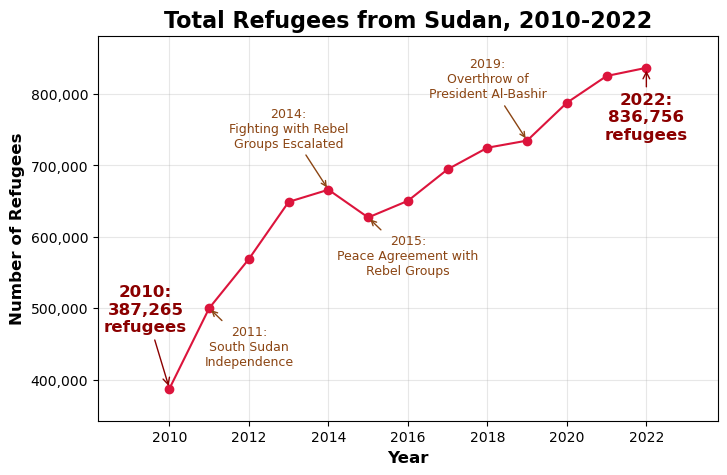

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

total = sudan.groupby('year')['refugees'].sum().reset_index()
total = total.sort_values('year')

plt.figure(figsize=(8,5))
plt.plot(total['year'], total['refugees'], marker='o', linestyle='-', color='crimson')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.title('Total Refugees from Sudan, 2010-2022', fontweight='bold', fontsize=16)
plt.xlabel('Year', fontweight='bold',fontsize=12)
plt.ylabel('Number of Refugees', fontweight='bold', fontsize=12)
plt.grid(True, alpha=0.3)
plt.margins(x=0.15, y=0.1)

# 4 major events annotation
events = {2011: '2011:\nSouth Sudan\nIndependence', 2015:
          '2015:\nPeace Agreement with\nRebel Groups'}
for year, event in events.items():
    if year in total['year'].values:
        y = total[total['year'] == year]['refugees'].values[0]
    else:
        y = total[total['year'] < year]['refugees'].values[-1]
    plt.annotate(event, xy=(year, y), xytext=(year+1, y-80000),
                 arrowprops=dict(color='saddlebrown', arrowstyle='->'),
                 fontsize=9, color='saddlebrown', ha='center')

events2 = {2014: '2014:\nFighting with Rebel\nGroups Escalated',
           2019: '2019:\nOverthrow of\nPresident Al-Bashir',}
for year, event in events2.items():
    if year in total['year'].values:
        y = total[total['year'] == year]['refugees'].values[0]
    else:
        y = total[total['year'] < year]['refugees'].values[-1]
    plt.annotate(event, xy=(year, y), xytext=(year-1, y+60000),
                 arrowprops=dict(color='saddlebrown', arrowstyle='->'),
                 fontsize=9, color='saddlebrown', ha='center')

# Number of refugees annotation
year = 2022
event = '2022:\n836,756\nrefugees'
if year in total['year'].values:
    y = total[total['year'] == year]['refugees'].values[0]
else:
    y = total[total['year'] < year]['refugees'].values[-1]
plt.annotate(event, xy=(year, y), xytext=(year, y-100000),
             arrowprops=dict(arrowstyle='->', color='darkred'),
    fontsize=12, color='darkred', ha='center', fontweight='bold')

year = 2010
event = '2010:\n387,265\nrefugees'
if year in total['year'].values:
    y = total[total['year'] == year]['refugees'].values[0]
else:
    y = total[total['year'] < year]['refugees'].values[-1]
plt.annotate(event, xy=(year, y), xytext=(year-0.6, y+80000),
             arrowprops=dict(color='darkred', arrowstyle='->'),
    fontsize=12, color='darkred', ha='center', fontweight='bold')

plt.show()

We see an overall significant upward trend in total Sudanese refugees. In **2010**, there were **387,265 Sudanese refugees** in countries all around the world. In **2022**, that number has doubled into **836,756 Sudanese refugees**. Here are some major events that happened in these 12 years:

#### 2011: South Sudan Independence
South Sudan became the world's newest country when it separated from Sudan. Since 1955, the two groups fought in two civil wars because of disputes over oil resources and cultural issues. A peace agreement was signed in 2005, and in 2011, it officially gained independnece.

#### 2014: Fighting with Rebel Groups Escalated
Fighting became more serious between government forces and rebel groups all across the country, especially in Darfur, South Kordofan, and Blue Nile. Millions of people were displaced.

#### 2015: Peace Agreement with Rebel Groups
Sudan signed a peace agreement with some rebel groups. Though refugee numbers dipped a little, it did not make a big difference. Refugee numbers continued to increase the year after.

#### 2019: Overthrow of President Al-Bashir
After months of protests, President Omar Al-Bashir was overthrown by the military. The government was replaced by a military power, and later, a joint civilian-military government was formed.

## Internally Displaced Persons in Sudan

In this graph, we will look at the change over years of internally displaced persons in Sudan.

#### *Internally Displaced Person (IDP)*
> **People who are forced to flee their homes by conflict, violence, persecution or disasters, but remain within their own country.**

The difference between an IDP and a refugee is that IDPs remain within the country, while refugees went outside of their country. However, both are *forced* to leave their own homes due to conflict.

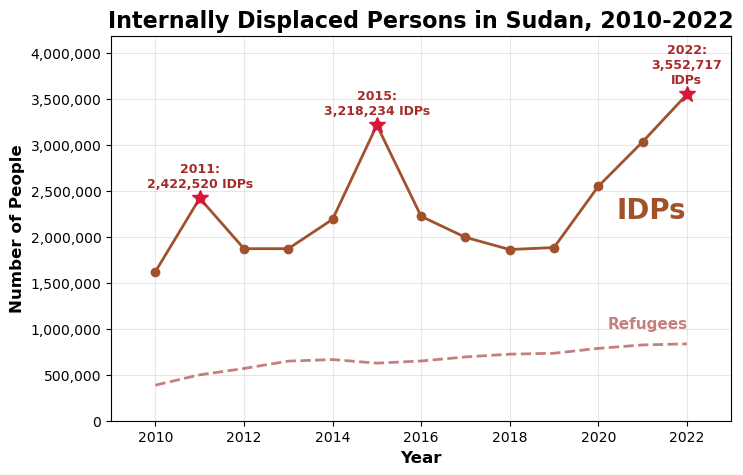

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

idp = sudan.groupby('year')[['refugees', 'idps']].sum().reset_index()
idp = idp.sort_values('year')

plt.figure(figsize=(8,5))
plt.plot(idp['year'], idp['idps'], label='IDPs', linewidth=2, marker='o', color='sienna')
plt.plot(idp['year'], idp['refugees'], linestyle='--', alpha=0.5, linewidth=2, label='Refugees', color='darkred')
plt.title('Internally Displaced Persons in Sudan, 2010-2022', fontweight='bold', fontsize=16)
plt.xlabel('Year', fontweight='bold', fontsize=12)
plt.ylabel('Number of People', fontweight='bold', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, alpha=0.3)
max_val = idp['idps'].max()
plt.ylim(0, max_val * 1.18)
plt.xlim(2009, 2023)

# Top 3 IDP years
events = {2011: '2011:\n2,422,520 IDPs', 2015: '2015:\n3,218,234 IDPs', 2022: '2022:\n3,552,717\nIDPs'}
for year, event in events.items():
    if year in idp['year'].values:
        y = idp[idp['year'] == year]['idps'].values[0]
    else:
        y = total[total['year'] < year]['idps'].values[-1]
    plt.annotate(event, xy=(year, y), xytext=(year, y+120000),
                 fontsize=9, color='brown', ha='center', fontweight='bold')

# Add stars
star_years = [2011, 2015, 2022]
stars = idp[idp['year'].isin(star_years)]
plt.plot(stars['year'], stars['idps'], '*', markersize=12, color='crimson')

# Add labels
plt.text(2020.4, 2200000, 'IDPs', fontsize=20, weight='bold', color='sienna');
plt.text(2020.2, 1000000, 'Refugees', fontsize=11, alpha=0.5, color='darkred', weight='bold');

The dark brown line is the number of IDPs, which are all extremely high with a minimum of **1,500,000 IDPs** a year. There are peaks at year 2011, 2015, and 2022 marked with a star.

The pink dotted line is number of refugees over time. There are around 3-6 times more IDPs than refugees in a given year. This tells us that dispaced Sudanese are more likely to stay in their country than to cross a national border.

#### **A major reason Sudanese people become refugees and IDPs is to flee from armed conflict and violence, economic crises, and severe food shortages. The Sudanese also face challenges in its climate, such as drought, floods, and deforestation.** 

## Countries Sudanese Refugees Flee to

Let's return to our topic of refugees. Which country do Sudanese people go to first to find safety? I will first focus on the year 2022 because this was a few years after the overthrow of President Al-Bashir, and the country could fully feel the effects of a militarized government.

#### *Country of Arrival (COA)*
> **the first country refugees reach after crossing an international border to flee persecution or danger from their home country.**

A refugee's COA is often a border country to their home country. Although many refugees stay in their first COA, some continue to move on to other nations. This may be due to additional safety concerns or hope for more stability and resources. 

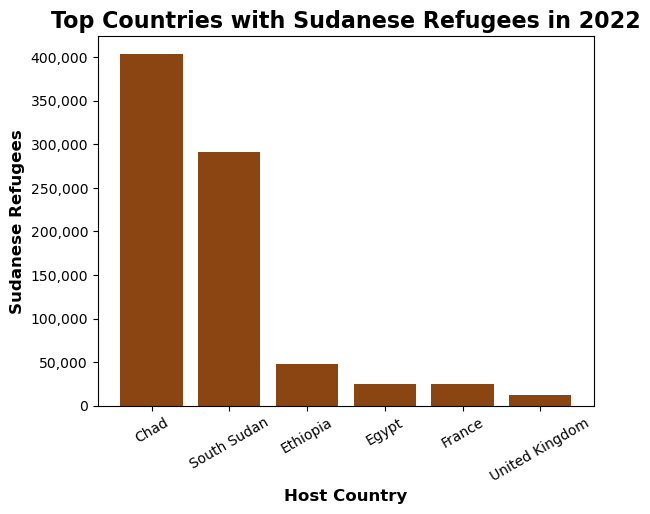

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

coa = (sudan[sudan["year"] == 2022].groupby("coa_name")["refugees"]
    .sum().sort_values(ascending=False))

top = coa.head(6)

plt.bar(top.index, top.values, color='saddlebrown')

plt.xlabel('Country of Arrival', fontsize=12, fontweight='bold')
plt.ylabel('Sudanese Refugees', fontsize=12, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.title('Top Countries with Sudanese Refugees in 2022', fontweight='bold', fontsize=16)

plt.xticks(rotation=30)

plt.show()

Sudanese refugees are most likely to cross into **Chad and South Sudan**, two border countries of Sudan. Other countries also have Sudanese refugees but they may be harder to get to, or place more restrictions on gaining refugee status.

#### Chad
Chad is *extremely generous*, holding more than 400,000 Sudanese refugees in 2022. This is quite significant considering that Chad's own population was approximately 18 million in 2022, which is around the same population as New York. Would you be able to imagine 400,000 people coming into New York, needing a place to live, sleep, and eat?

#### South Sudan
Even though South Sudan is also facing its own internal conflict, more than 290,000 Sudanese refugees fled to South Sudan in 2022. This was likely a physically and culturally better option for many.

#### Ethiopia and Egypt
Refugee camps in Ethiopia and Egypt struggle to host more refugees. Additionally, the influx of refugees, has caused Egypt to place more restrictions on refugees crossing the border or obtaining visa. 

#### France and UK
Sudanese refugees often navigate treacherous journeys to get to Europe. They would cross into Chad, Libya, the Mediterranian Sea, France, then arrive at the UK. Those who cross through the Mediterranean Sea to go to Europe may risk their life. Unfortunately, many die crossing into nations trying to escape their home country.

## Country of Arrival Distributions of Sudanese Refugees
Next, I will create a box plot of Sudanese refugees over the time period of 2010-2022. It will display the median, quartile ranges, and any outliers in the number of refugees the country hosts per year.

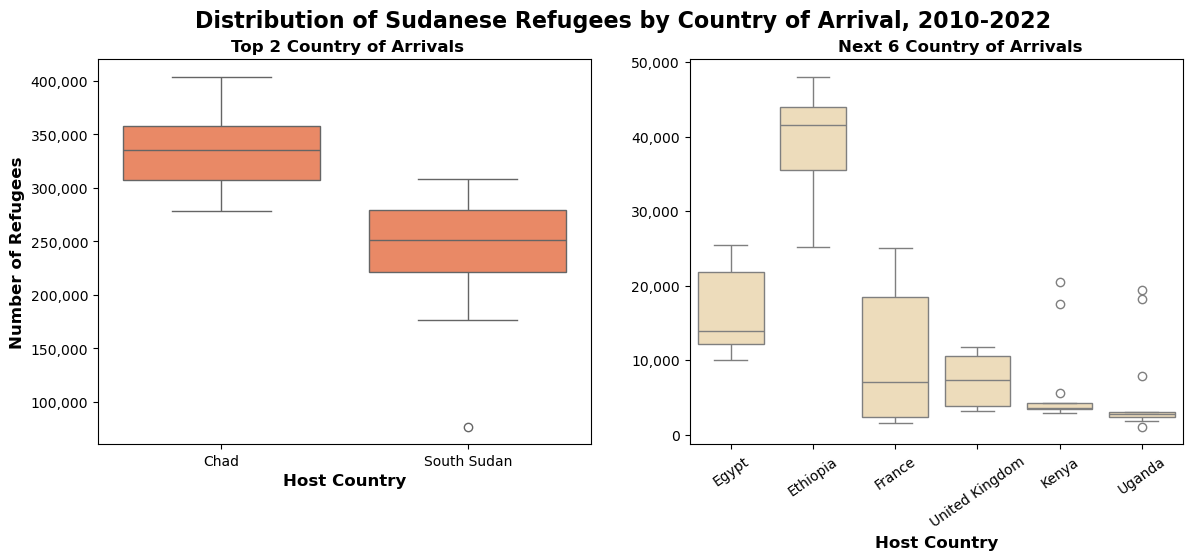

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# LEFT: Top 2
top = (sudan.groupby('coa_name')['refugees'].sum()
    .sort_values(ascending=False).head(2).index)

subset = sudan[sudan['coa_name'].isin(top)]

sns.boxplot(data=subset, x='coa_name', y='refugees', ax=axes[0], color='coral')

axes[0].set_xlabel('Host Country', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Refugees', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# RIGHT: Next 6
top = (sudan.groupby('coa_name')['refugees'].sum()
    .sort_values(ascending=False)[2:8]
    .index)

subset = sudan[sudan['coa_name'].isin(top)]

sns.boxplot(data=subset, x='coa_name', y='refugees', ax=axes[1], color='wheat')

axes[1].set_xlabel('Host Country', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))


# TITLE
axes[1].set_xlabel('Host Country', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)

fig.suptitle('Distribution of Sudanese Refugees by Country of Arrival, 2010-2022',
             fontsize=16, fontweight='bold')
axes[0].text(0.27, 1.02, 'Top 2 Country of Arrivals',
             transform=axes[0].transAxes,
             fontsize=12, fontweight='bold')

axes[1].text(0.30, 1.02, 'Next 6 Country of Arrivals',
             transform=axes[1].transAxes,
             fontsize=12, fontweight='bold')

axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

We already know that Chad and South Sudan host the most Sudanese refugees. The number of refugees in Chad has varied from approximately **280,000 to 400,000** a year, and its median number of refugees is approximately **330,000** a year. South Sudan has a median of **250,000** refugees a year and has one outlier of hosting less than 100,000 a year.

On the right, there are a two new countries that appeared: Kenya and Uganda. The median of the two are approximately at 2,000 refugees, but they have multiple outliers of up to 20,000.

## Returned Sudanese Refugees

In this section, I will look at the years Sudanese refugees returned to Sudan, their home country.

#### *Returned Refugee*: 
> **a former refugee or internally displaced person who has voluntarily returned to their country or area of origin to remain their permanently.**

A refugee may return home once they know their home is now safe and stabilized. However, as you have seen from above, the conflict in Sudan hasn't improved, but refugees may still choose to return home despite ongoing conflict. This is due to:

* Extreme homesickness
* Wanting to see family and friends
* Economic and social challenges in the country of arrival
  * This includes challenges in learning a new language, discrimination, and lack of jobs for refugees
  * An experienced doctor from Sudan may have to work at a grocery store in France because the host country does not accept certifications from another country.

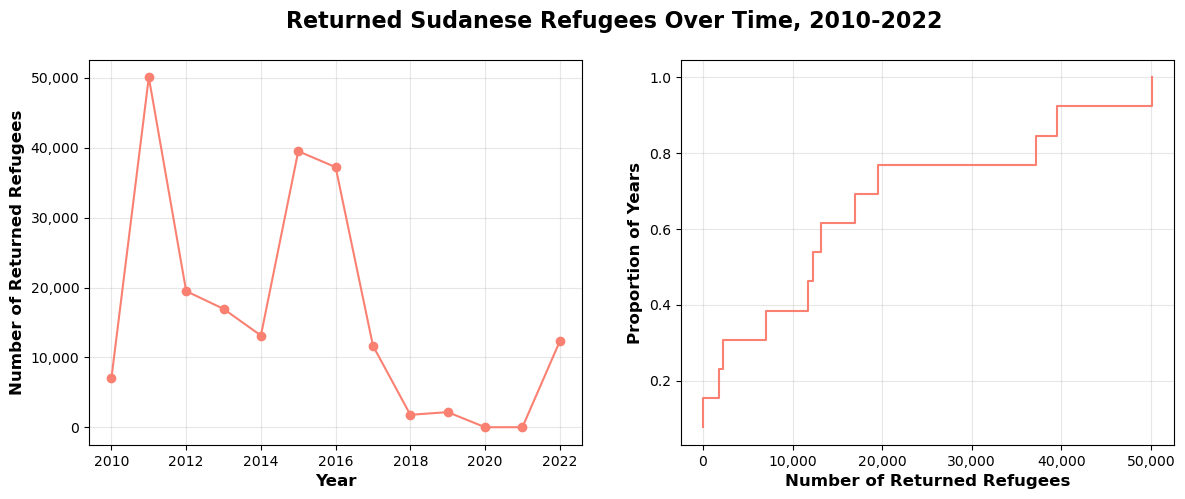

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

returned_total = sudan.groupby('year')['returned_refugees'].sum().reset_index()
returned_total = returned_total.sort_values('year')

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Left: Line
axes[0].plot(returned_total['year'], returned_total['returned_refugees'],
             marker='o', color='salmon')
axes[0].set_xlabel('Year', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Returned Refugees', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: ECDF
data = np.sort(returned_total['returned_refugees'].values)
y = np.arange(1, len(data)+1) / len(data)

axes[1].step(data, y, where='post', color='salmon')
axes[1].set_xlabel('Number of Returned Refugees', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Proportion of Years', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Returned Sudanese Refugees Over Time, 2010-2022', fontweight='bold', fontsize=16);

**According to the graph on the left**, returned refugees were particularly high in the years **2011, 2015, and 2016**. I wasn't able to find information on why these years had spikes, however, here are my *speculations*:

#### 2011:
This was the year of the South Sudan Independence, and refugees believed that the conflict between Sudan and South Sudan has ended. The Sudanese may have saw this as a new, fresh start for the two countries, and decided to return and build a new life.

#### 2015-2016:
As noted in my first graph, "Total Refugees from Sudan, 2010-2022", the year 2015 was when the government signed a peace agreement with rebel groups. Sudanese refugees who heard this news abroad may have help on to hope that events were going to improve and returned to Sudan.

**According to the graph on the right**, the number of returned refugees from 2010 to 2022 are mostly between **0-20,000** returned refugees. Once the number reaches ~38,000, it begins to increase slightly again.

## Refugees from Other Countries to Sudan

You may be surprised to find out that despite Sudan's political and economic state, refugees from other countries may come into Sudan. Its location at the Horn of Africa makes it a key country for travellers to stop by and seek safety. Here, I will graph the number of refugees coming into Sudan from five different countries.

In [9]:
sudan2 = refugee.loc[refugee['coa_name'].isin(['Sudan'])]

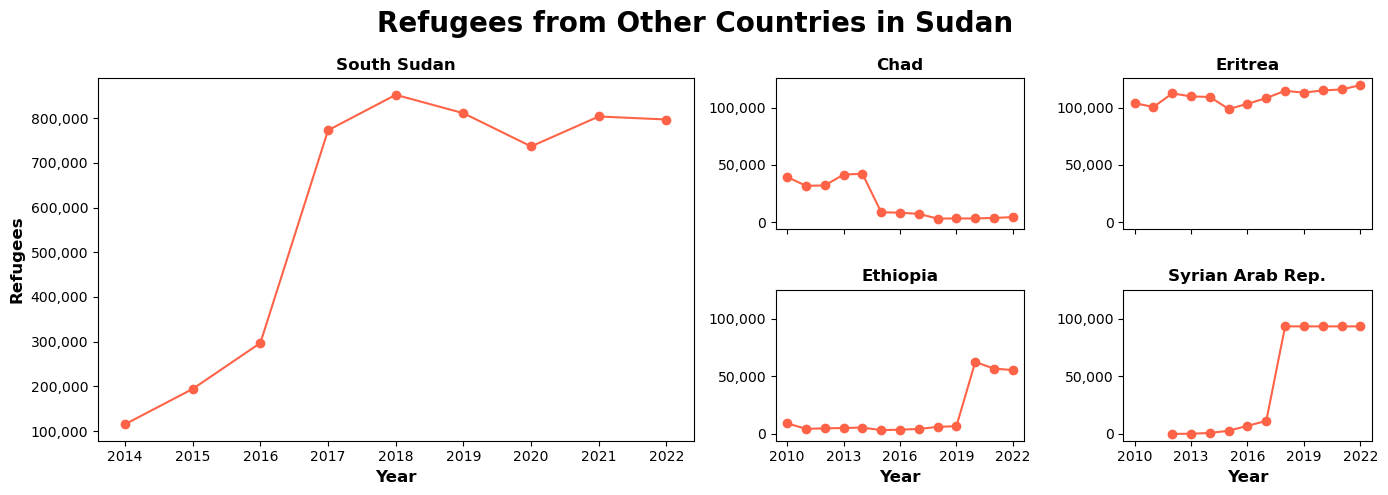

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpecFromSubplotSpec

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

sudan2 = sudan2.sort_values(['coo_name', 'year'])

# LEFT: South Sudan
south_sudan = sudan2[sudan2['coo_name'] == 'South Sudan']

axes[0].plot(south_sudan['year'], south_sudan['refugees'], marker='o', color='tomato')
axes[0].set_title('South Sudan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Refugees', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# RIGHT: Other countries
others = sudan2[sudan2['coo_name'].isin(['Chad', 'Eritrea',
    'Syrian Arab Rep.', 'Ethiopia'])]

gs = GridSpecFromSubplotSpec(2, 2,
    subplot_spec=axes[1].get_subplotspec(),
    wspace=0.4, hspace=0.4)

countries = others['coo_name'].unique()
shared_ax = None

for i, country in enumerate(countries):
    if shared_ax is None:
        ax = fig.add_subplot(gs[i])
        shared_ax = ax
    else:
        ax = fig.add_subplot(gs[i], sharey=shared_ax, sharex=shared_ax)

    data = others[others['coo_name'] == country]

    ax.plot(data['year'], data['refugees'], marker='o', color='tomato')
    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    if i < 2:   # top row
        ax.tick_params(axis='x', labelbottom=False)
    ax.set_xticks(range(2010, 2023, 3))
    
    if i >= 2:
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')

axes[1].axis('off')

plt.suptitle('Refugees from Other Countries in Sudan, 2010-2022', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

#### South Sudan
Refugees from South Sudan came into Sudan in large amounts, from approximately **100,000 refugees in 2014** to more than **700,000 by the year 2017**. This was because of new conflict that broke out in 2013, only two years after their new independence. Over 83% of those who fled are children and women, and many children are alone having been separated from their parents.

#### Chad
Though Chad is known for hosting countries from other countries, there were smaller numbers of refugees from Chad in years 2010 to 2015. This was mostly because of violence and instability in the eastern region.

#### Eritrea
President Isais Afwerki has ruled the country since 1993 and has crushed all political opposition and completely restricted freedom of speech and press. Military service in Eritrea is mandatory for men and women 18 and older. However, most are forced to serve an indefinite amount of time, much longer than expected. Many describe this service as, "being a slave to your own state," and as a result, people flee the country.

#### Ethiopia
Clashes between the Ethiopian government and the Tigray forces beginning in 2020 has caused many to go through its northern border into Sudan.

#### Syria
The Syrian refugee crisis in the Middle East began in 2013, but Syrian refugees didn't began to largely appear in Sudan in 2018. Sudan openly welcomed Syrian refugees and allowed them to work in the country visa-free until 2022. This also explains why the number has stayed the same from 2018 to 2022.

## Conclusion

### Sudan in Recent Years

My data only focused on the years 2010 to 2022. Unfortunately, the situation has not improved, and in fact has gotten worse. In 2023, Sudan faced the start of a civil war between the Sudancese Armed Forces and the Rapid Support Forces, which is still continuing on today. In the first line graph, we saw that the highest number of refugees per year was 800,000+, in 2022. After researching current articles, I found out that number has increased to nearly **4 million refugees** today, in 2026.

### Design Walkthrough

For every chart, I formatted the titles, subtitles, and labels a similar way. All titles have a 16 point font, and all other labels have a 12-14 point font. I bolded all of the words and annotations that needed to stick out. Overall, each graph's line has a red/orange/brown color to signify the overall importance.

To focus on one specific graph, I put the most detail on the second graph ("Internally Displaced Persons in Sudan, 2010-2022"). The solid, dark brown IDP line was meant to stand out the most, while the light red refugee line should be in the background. I wanted people to still see the difference between number of refugees and IDPs while ensuring the IDPs are the highlight. I added stars at the three peaks of the graph: year 2011, 2015, and 2022. Each star also has a numbered label with number of IDPs.

### Reflection

When visualizing the data, a challenge I faced was the large differences between countries in refugee numbers. For example, the #1 country with Sudanese refugees is Chad with an average of 330,000 refugees, and the #3 country is Ethiopia with just 41,000 refugees. This is a stark difference between the two countries and if I put them on the same chart, it would not be visually appealing. To solve this problem, I formatted two charts with different y-axes side by side. I put Chad and South Sudan's box plot onto the left chart as axis 0, and the rest of the countries with less refugees on axis 1. This way, all box plots would be fully shown and easy to read. I did the same thing with the "Returned Sudanese Refugees Over Time" Graph.

I believe the first visualization, "Total Refugees from Sudan, 2010-2022", best communicates my main insight. Its color is eye-catching and immediately shows people the seriousness of the issue. The annotations, such as the overthrow of the president or the signing of peace agreements also help explain the reasons behind certain decrease or increase in refugees. I also added bolded labels that numbered the massive increase from 2010 to 2022.

Overall, this was a meaningful assignment for me to shed light towards refugees from Sudan. Nearly everybody has heard of Ukrainian refugees, but very few news sources cover the ongoing conflict in Sudan. Both countries face enormous conflicts resulting in millions of refugees and IDPs, and it is important for people to know about each group. Hopefully, the situation in Sudan will improve and and all Sudanese and refugees from neighboring countries can one day safely return home.

![Sudanese women and children waiting to receive help in Chad's Ouaddaï region.](sudanese.jpg)